# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.fig_origins import FigureOrigins
fig_origins = FigureOrigins('output/draft4_run/')
fig_origins.setup_data()

Creating directory: output/draft4_run//figure_origins...Directory exists. Skipping.
Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [3]:
fig_origins.setup_processors(force_recompute=False)

Creating directory: output/draft4_run//figure_origins/fork_progression...Directory exists. Skipping.
Loading cached fork progression matrices from disk...
Creating directory: output/draft4_run//figure_origins/fork_progression...Directory exists. Skipping.
Loading cached fork progression matrices from disk...
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints
0/49 - 00:00:01.001
10/49 - 00:00:17.479
20/49 - 00:00:27.335
30/49 - 00:00:36.282
40/49 - 00:00:44.987
0/50 - 00:00:00.865
10/50 - 00:00:09.590
20/50 - 00:00:22.177
30/50 - 00:00:32.533
40/50 - 00:00:41.708


Saved figure to: output/draft4_run//figure_origins/origin_replication_times.png
Saved figure to: output/draft4_run//figure_origins/early_origin_enrichments.png
Saved figure to: output/draft4_run//figure_origins/cumulative_early_origin_enrichments.png
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 12
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr12.h5, crick_rna_seq_pileup_rep1_chr12.h5
Shape: (16, 1078177) (timepoints x positions)
Loaded p

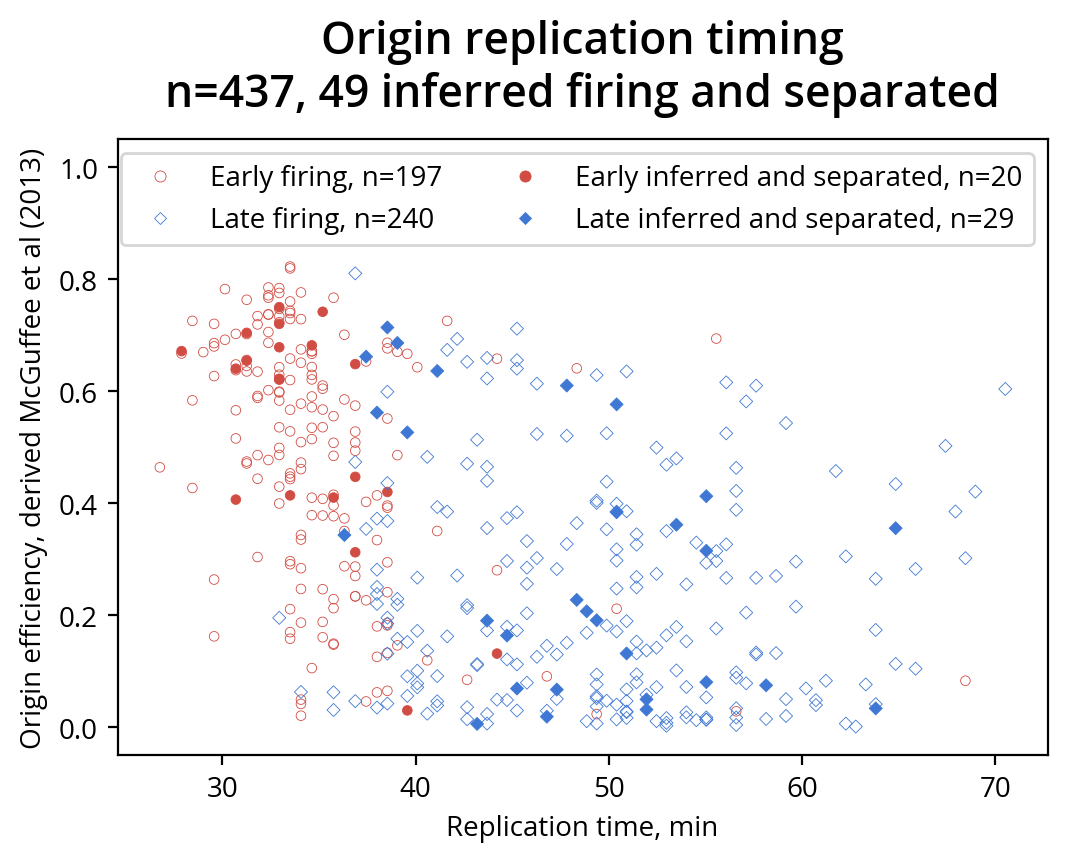

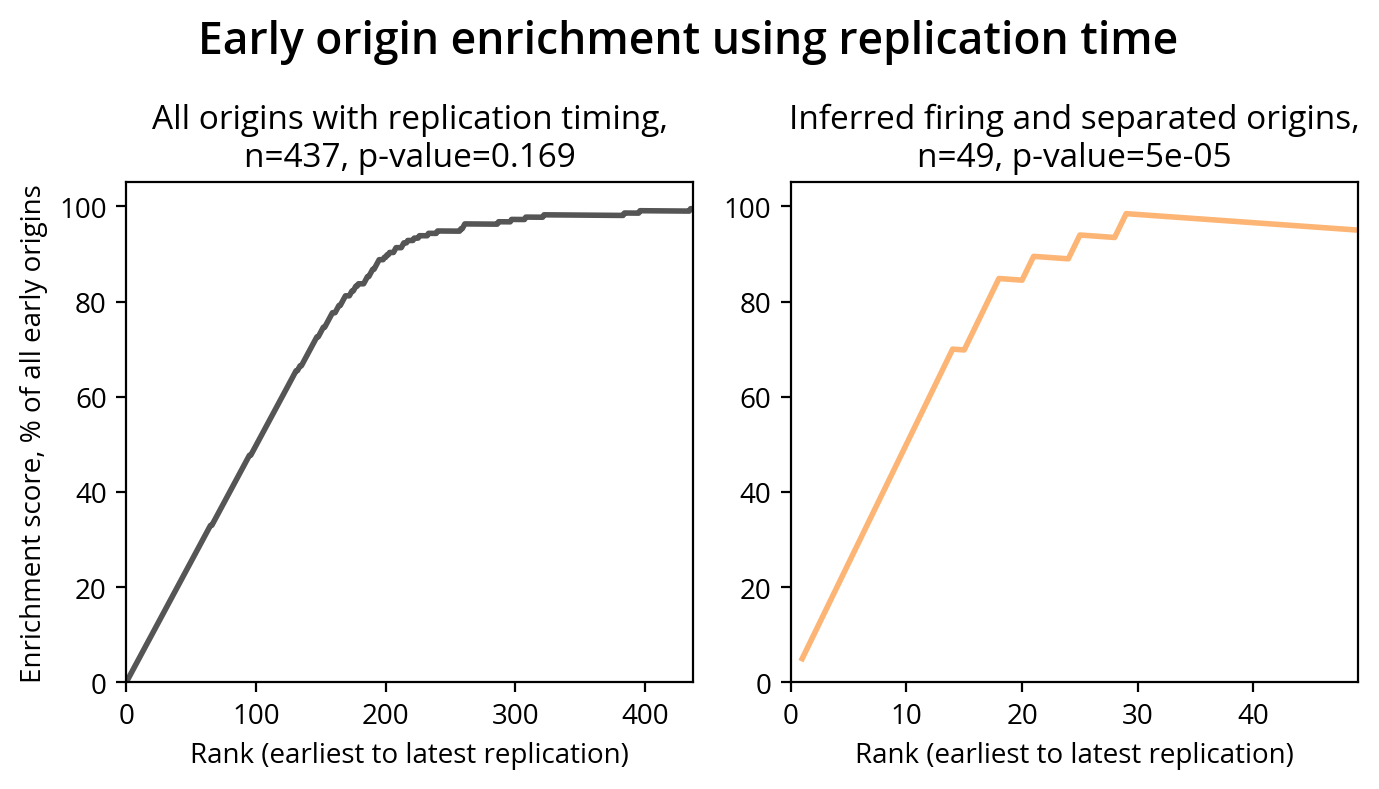

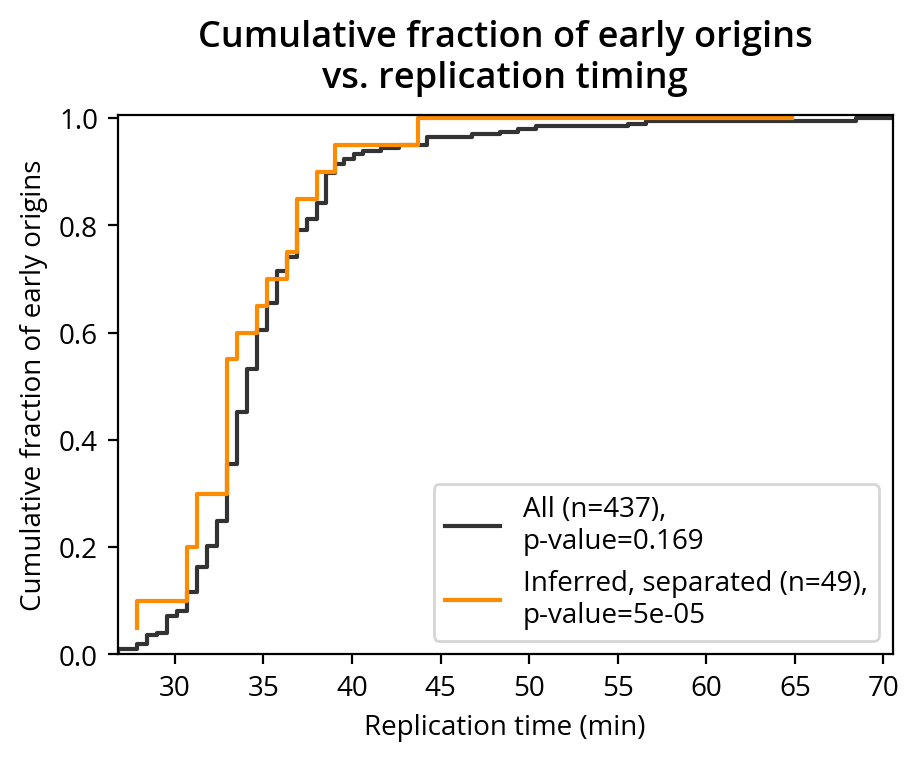

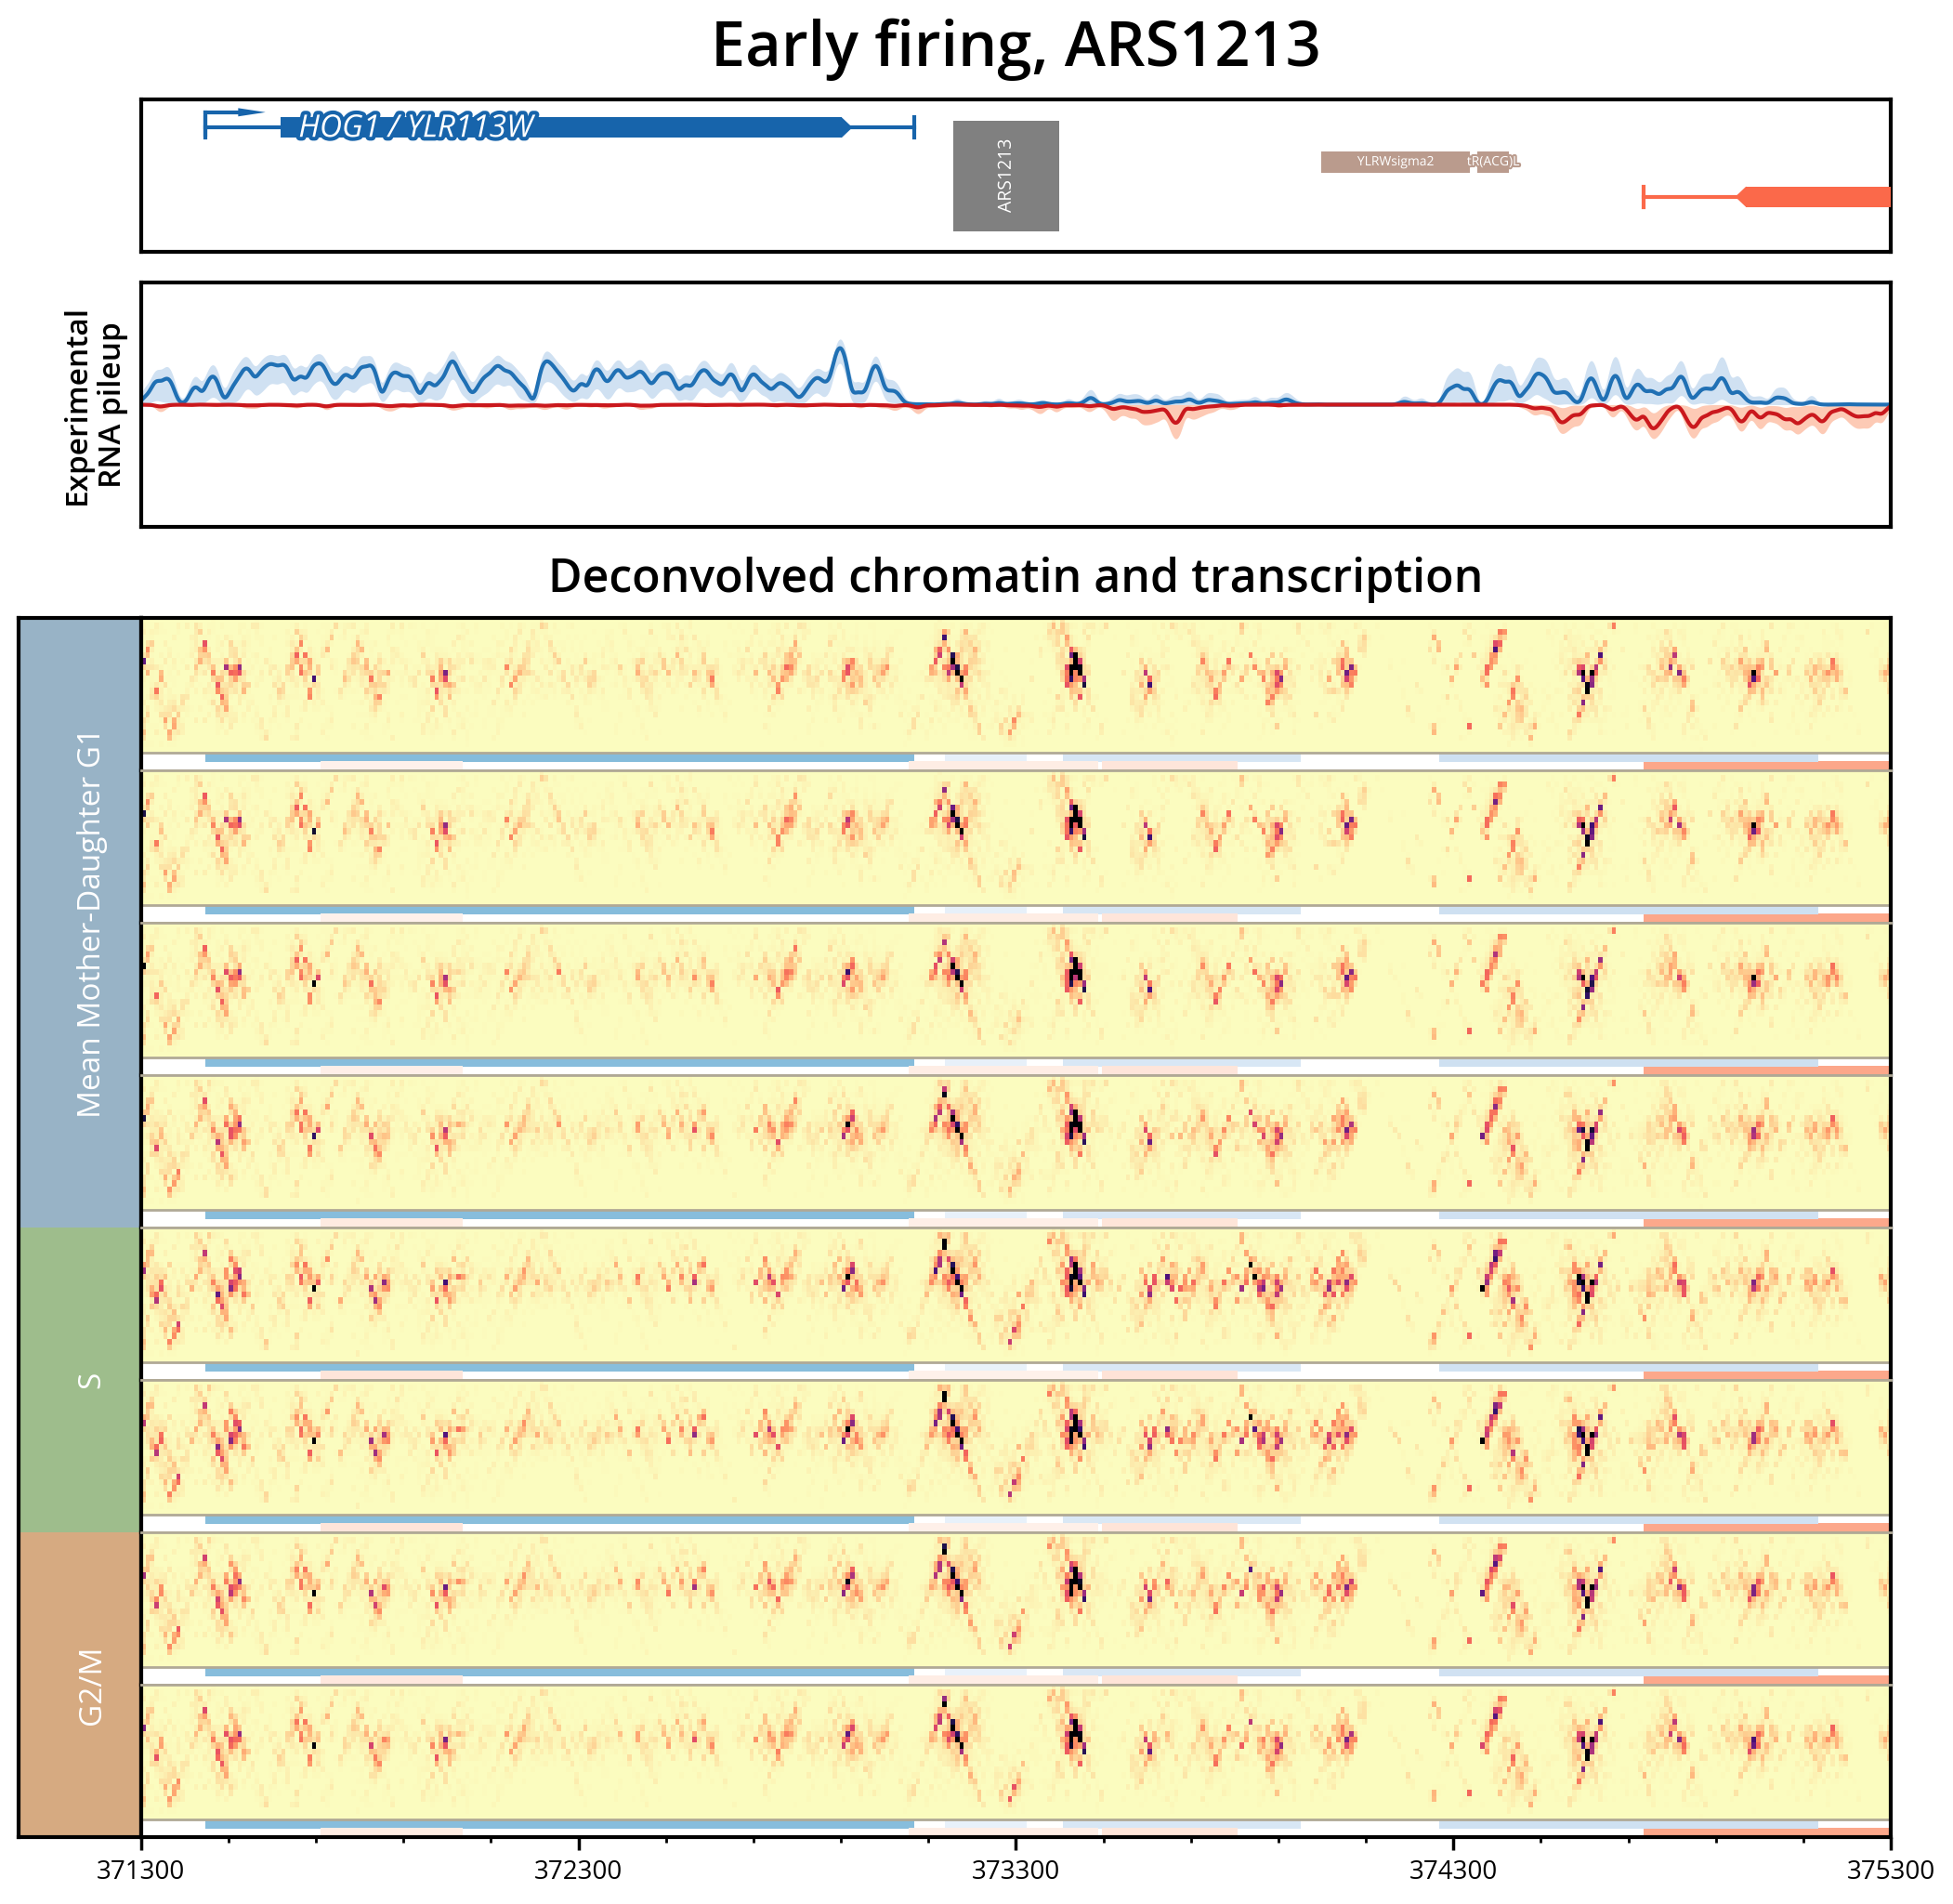

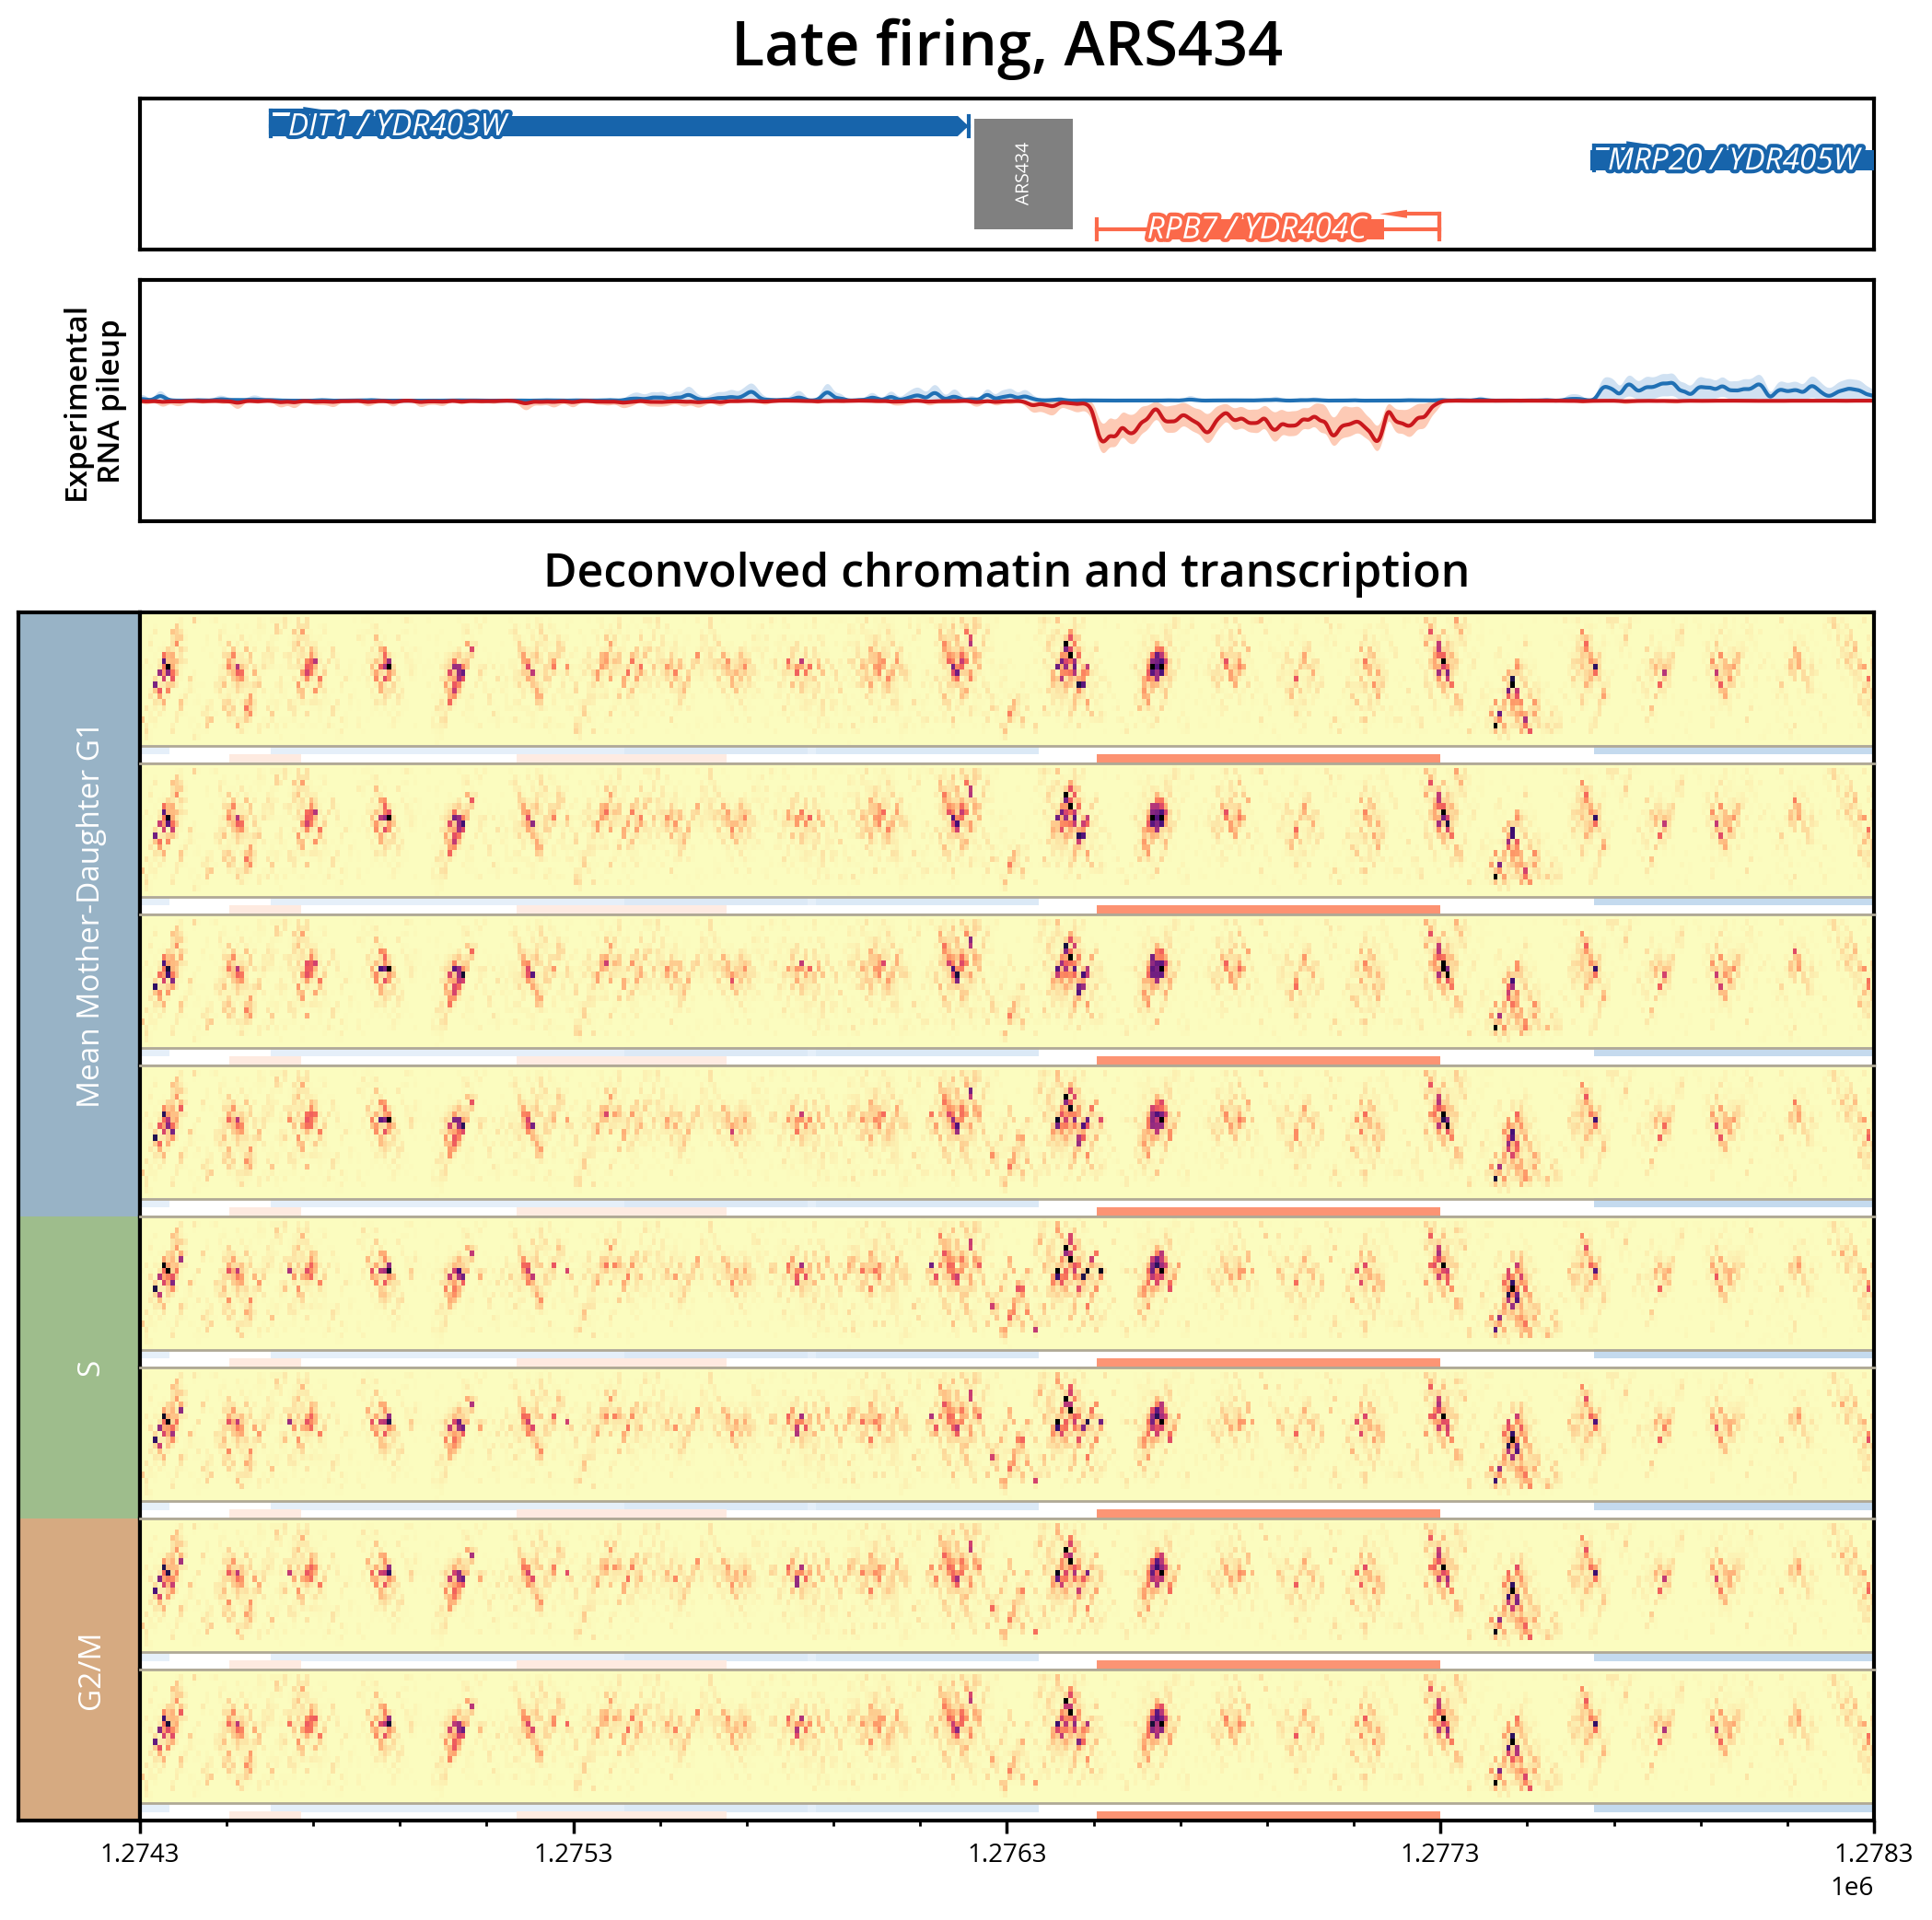

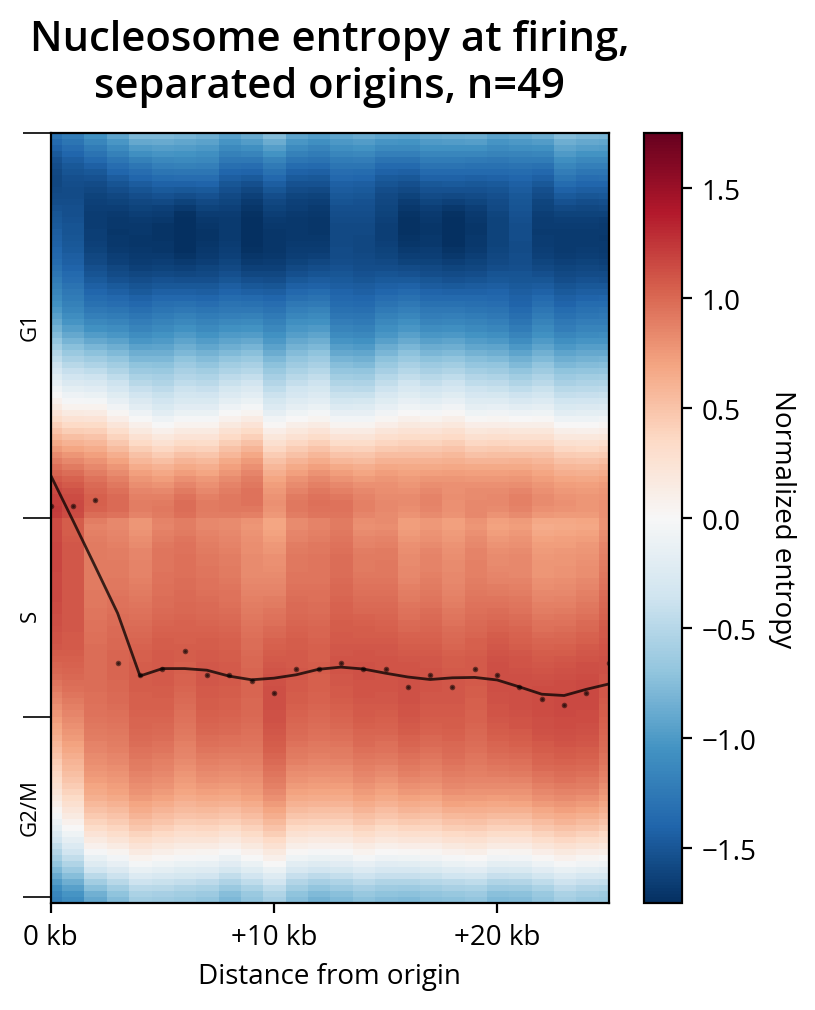

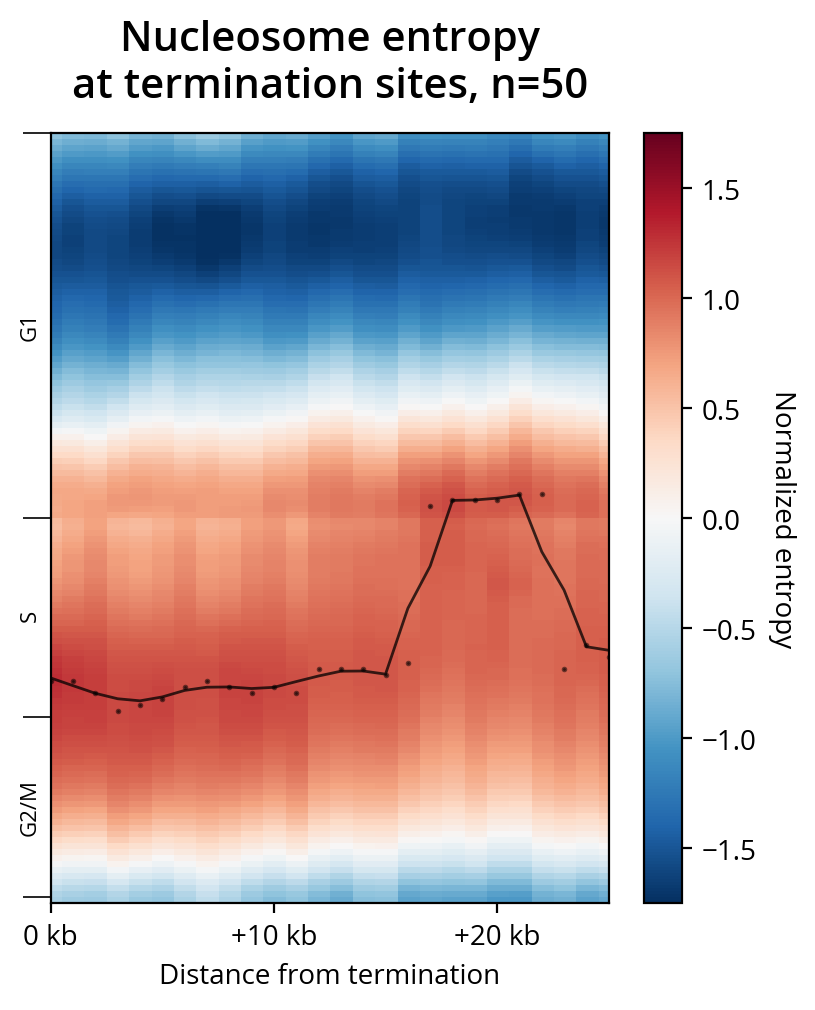

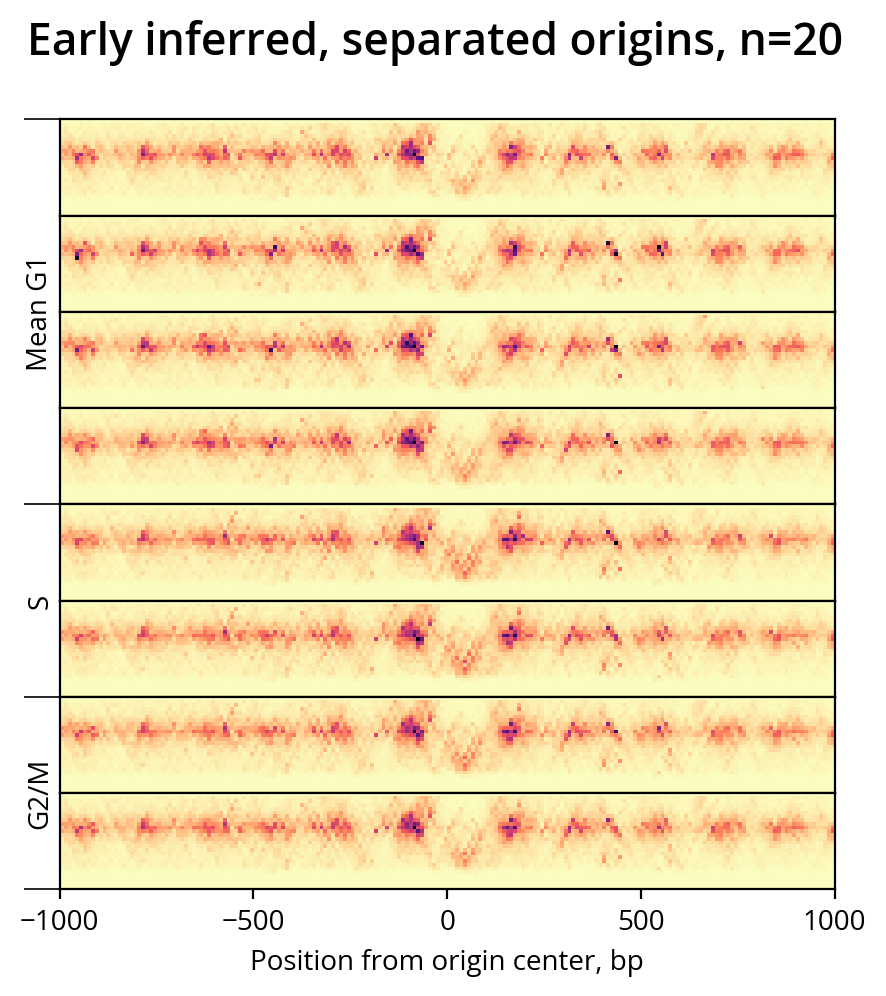

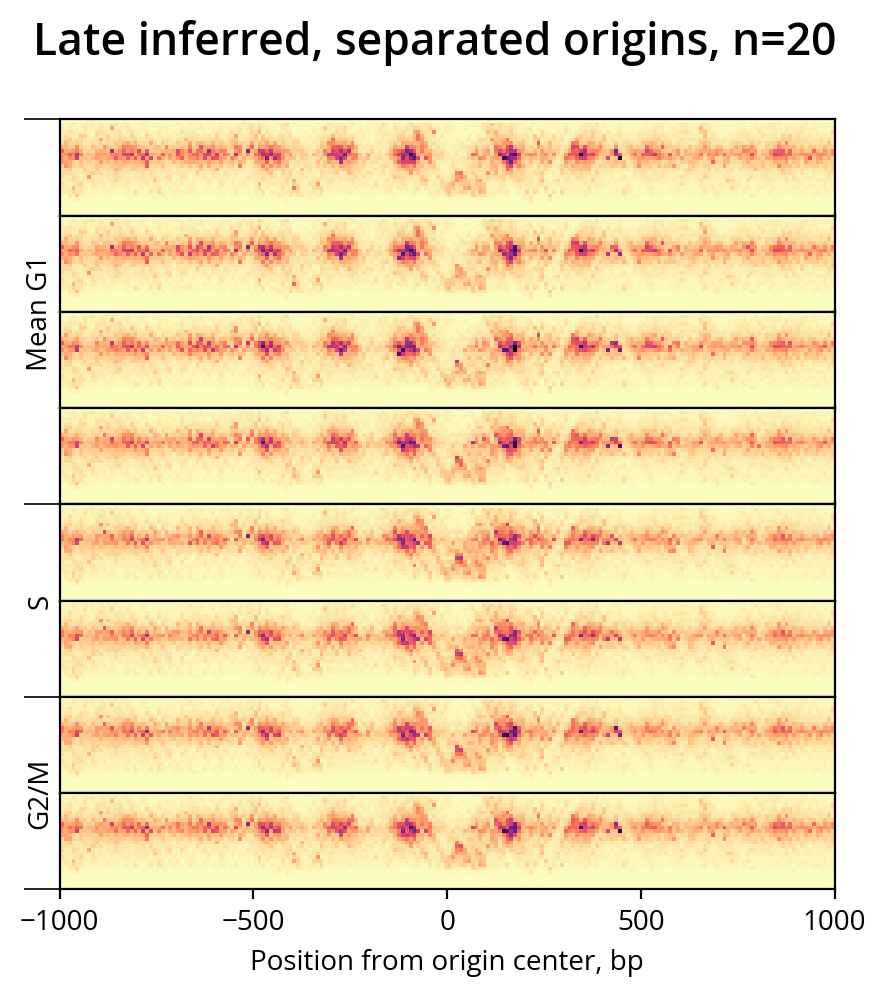

In [17]:
fig_origins.plot_all()

Debug figure saved to: output/draft4_run//Figures/Debug/Supplemental4.2_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental4.2_Origins.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Supplemental4.2_Origins.png


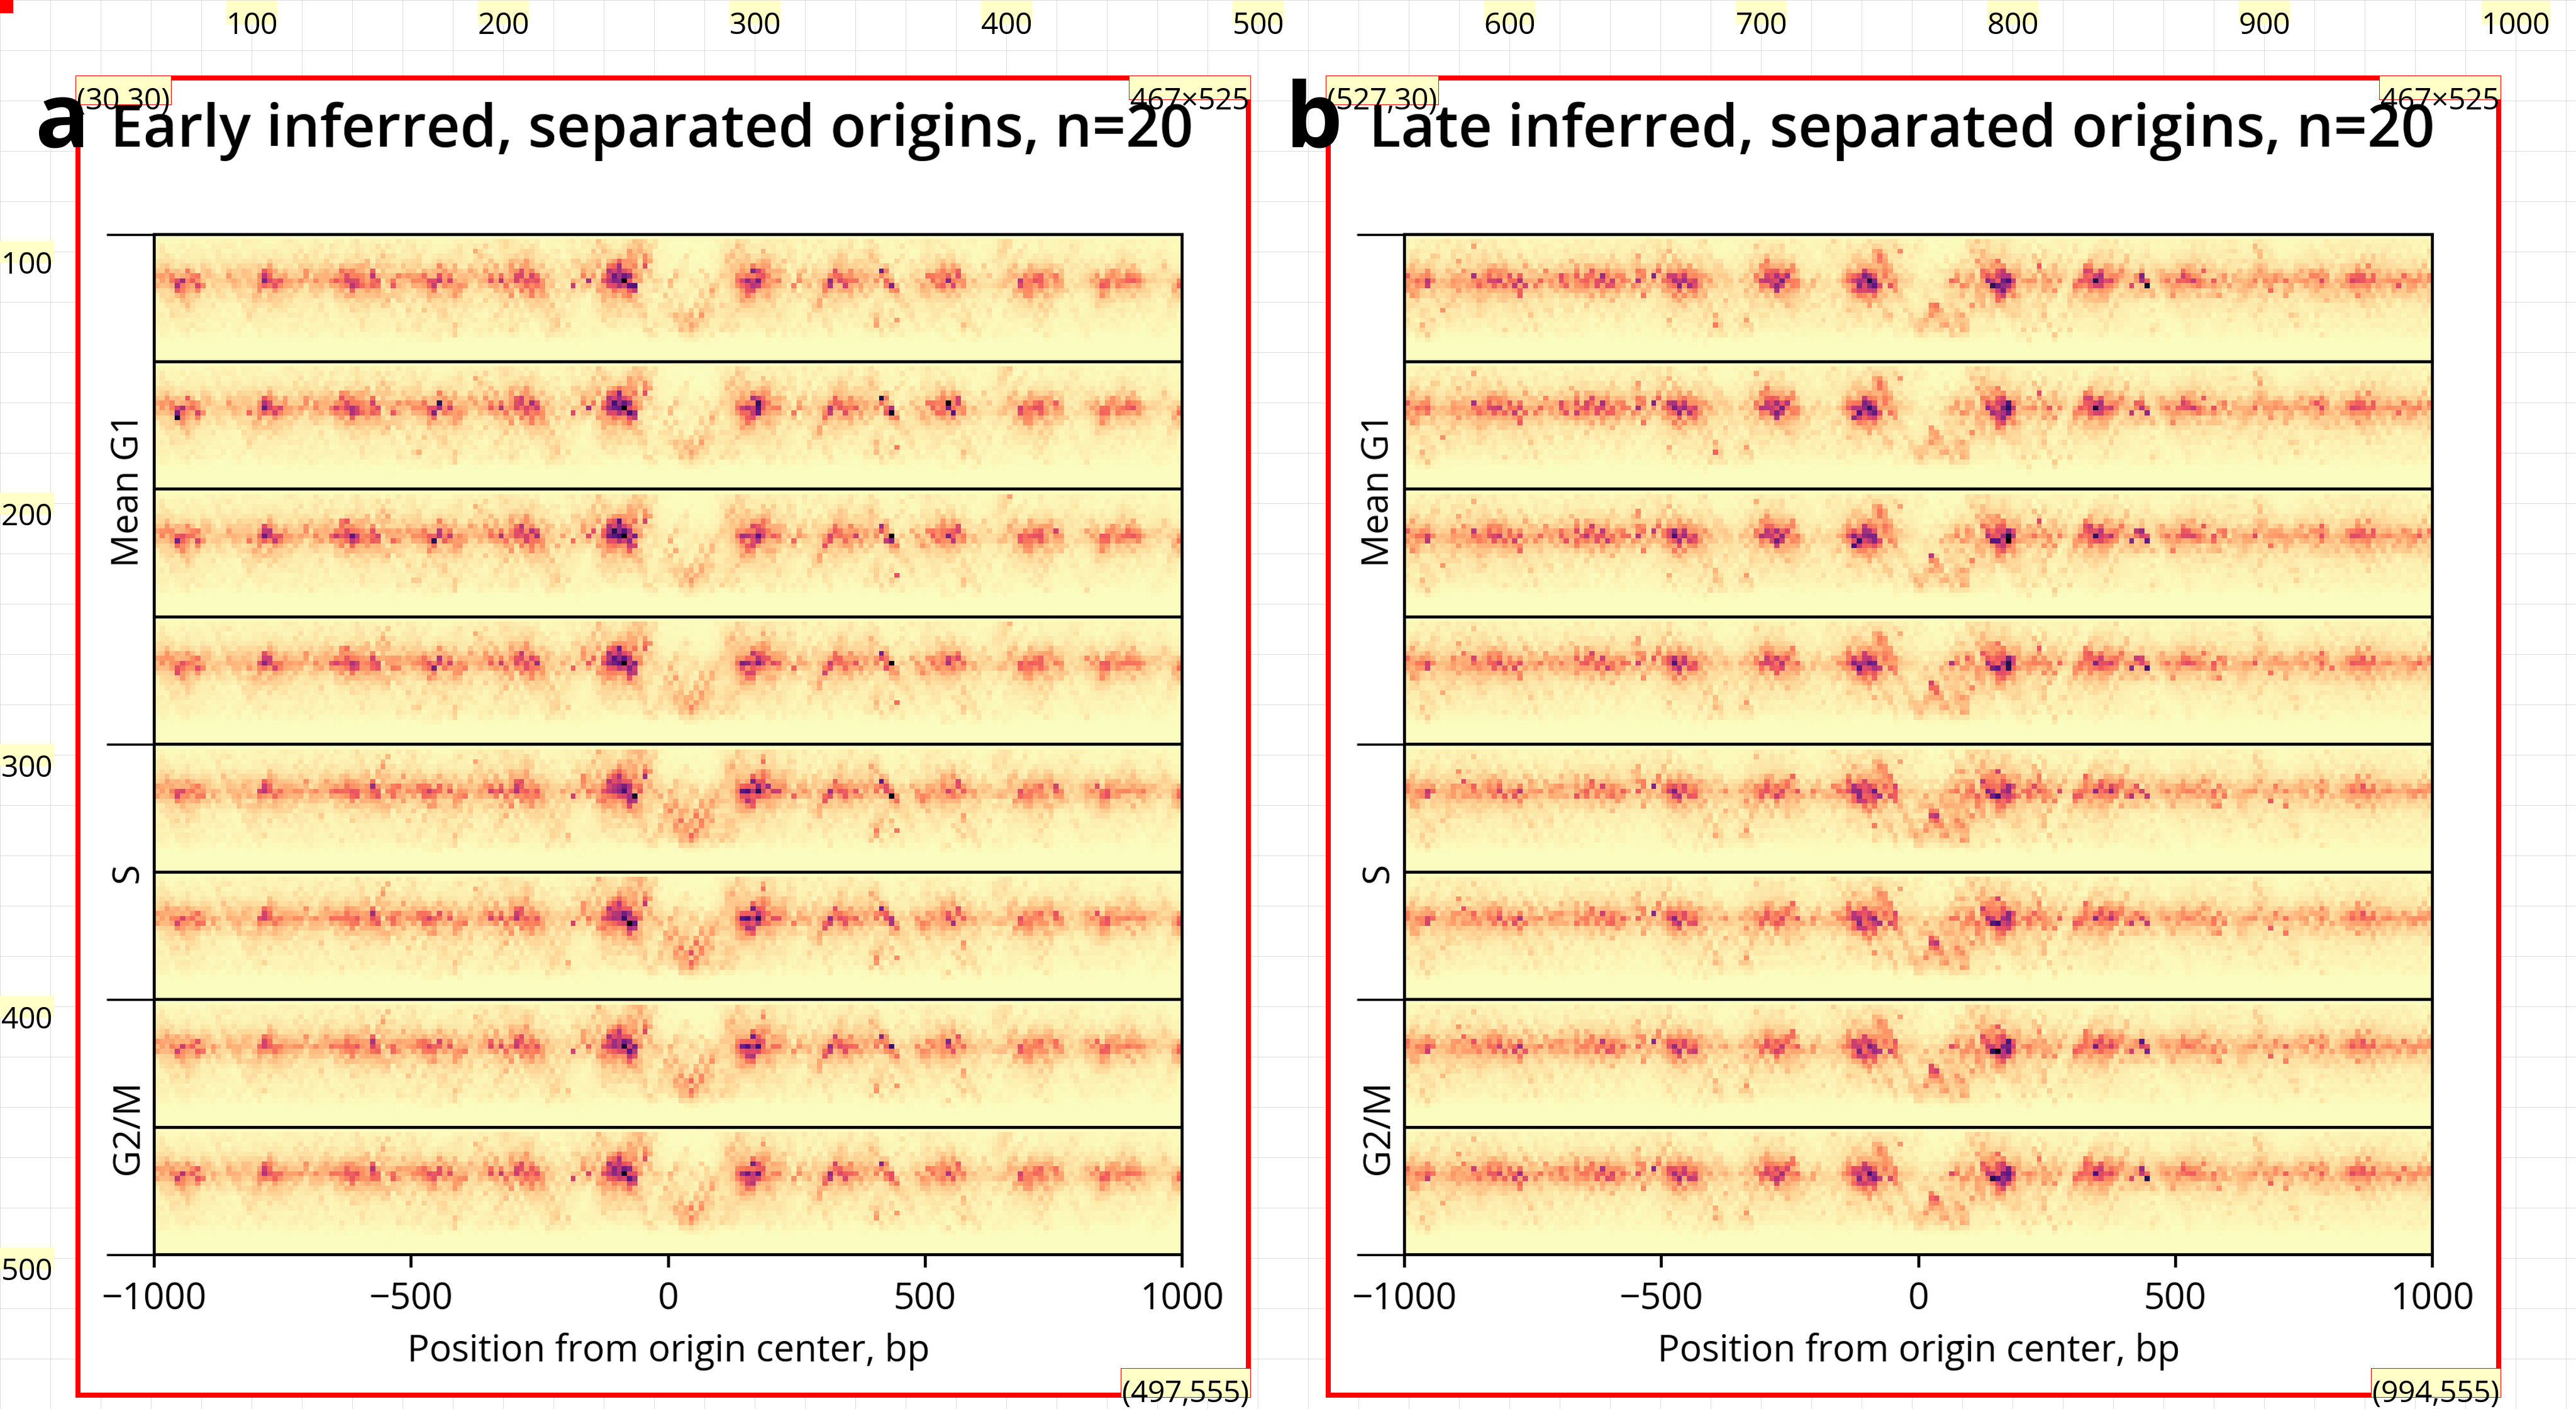

In [15]:
from IPython.display import Image, display

fig_origins.layout_supplemental_panel()
display(Image('output/draft4_run/Figures/Debug/Supplemental4.2_Origins_debug.png'))

Debug figure saved to: output/draft4_run//Figures/Debug/Supplemental2.7_Replication_Origins_Validation_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental2.7_Replication_Origins_Validation.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Supplemental2.7_Replication_Origins_Validation.png


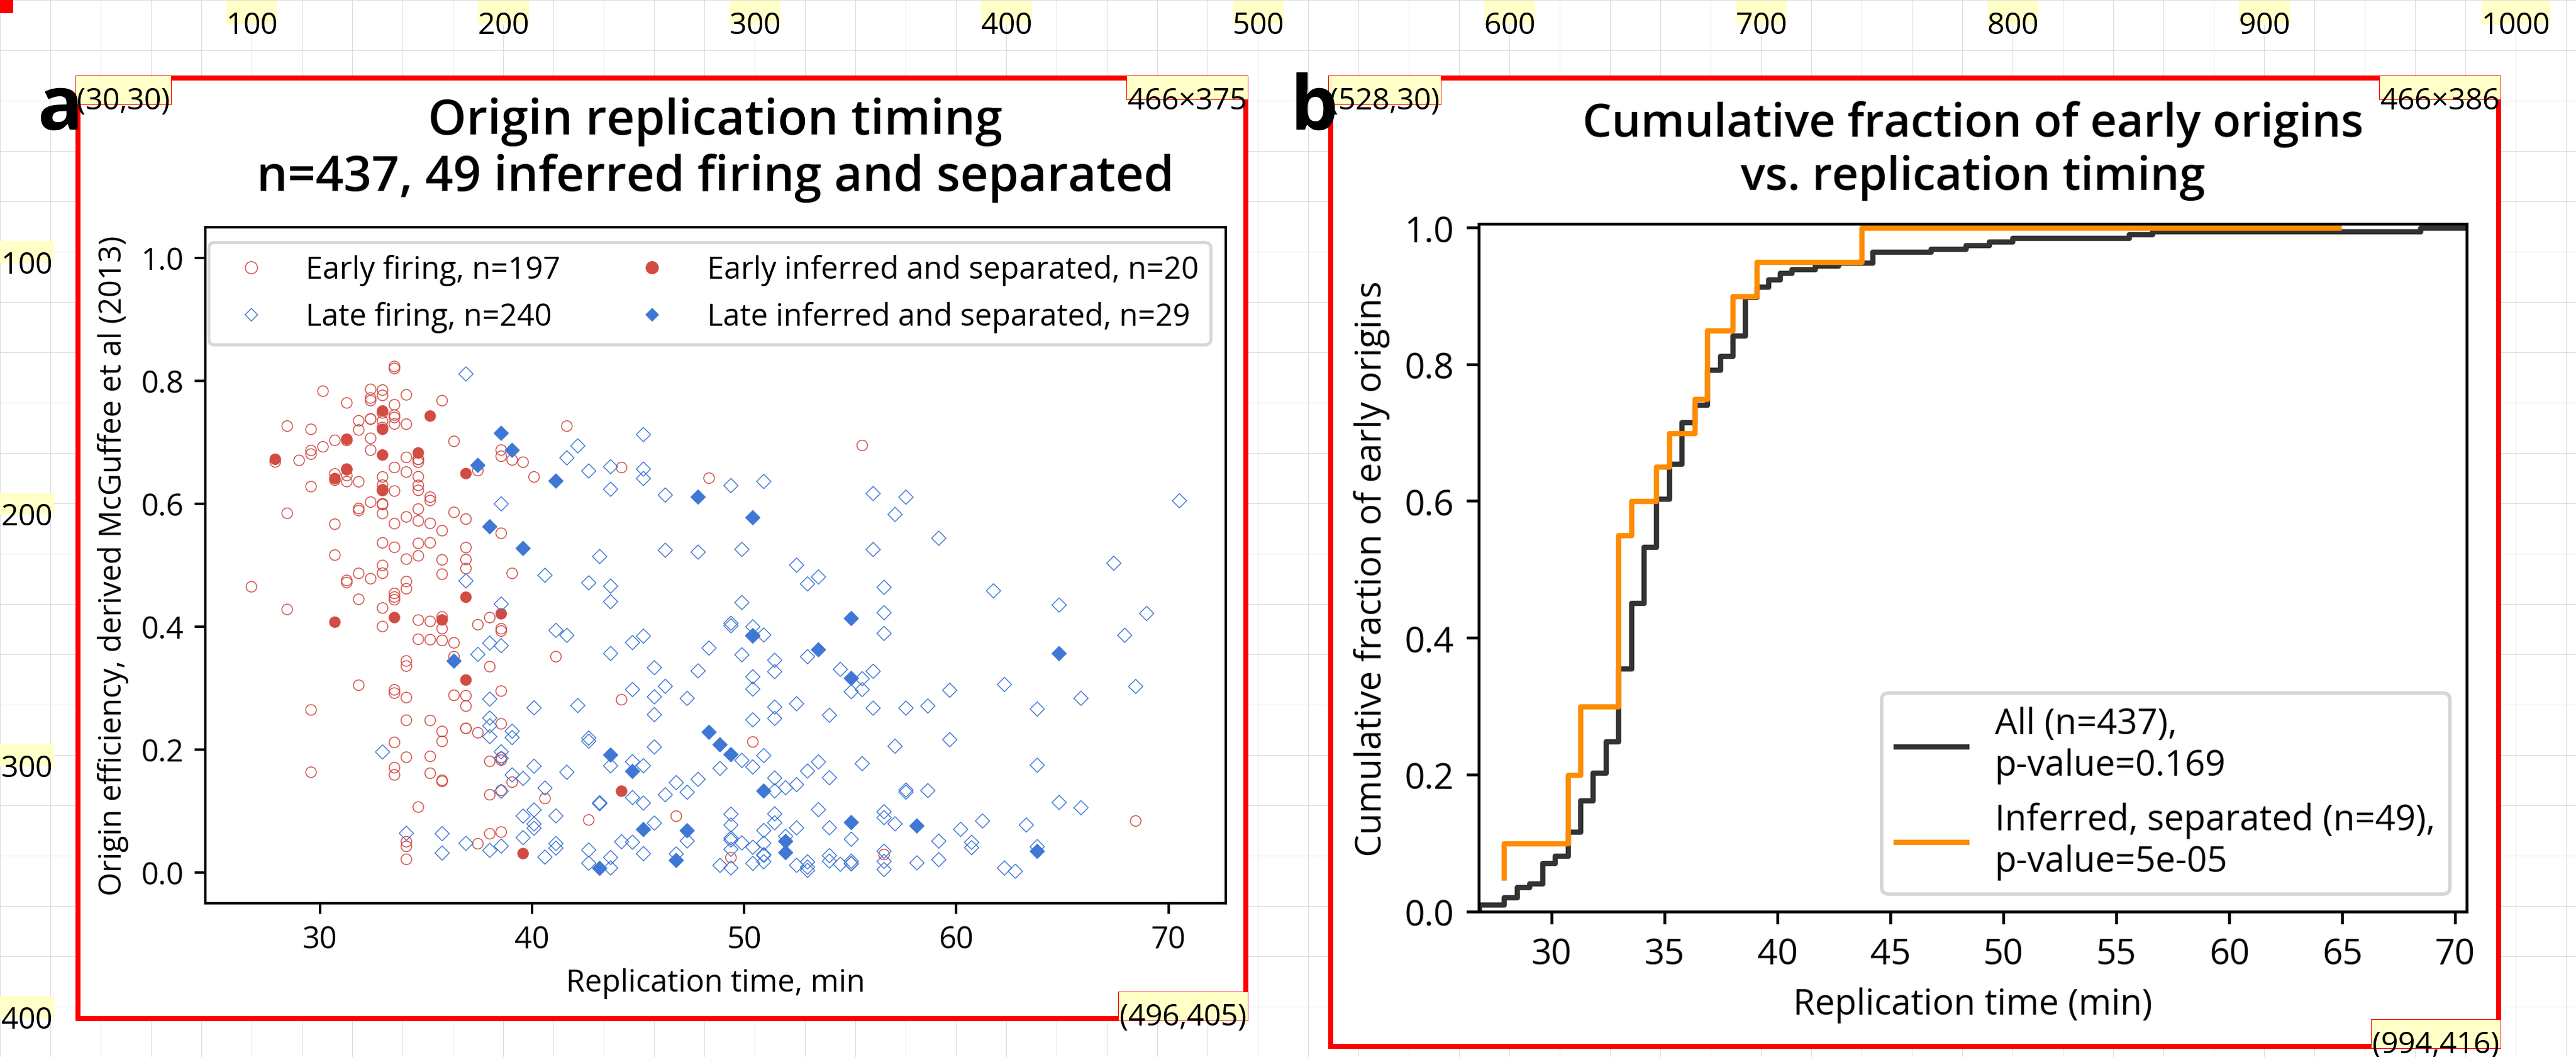

In [6]:
fig_origins.layout_supplemental_replication_origins_validation()
display(Image('output/draft4_run/Figures/Debug/Supplemental2.7_Replication_Origins_Validation_debug.png'))


Debug figure saved to: output/draft4_run//Figures/Debug/Figure4_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Figure4_Origins.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Figure4_Origins.png


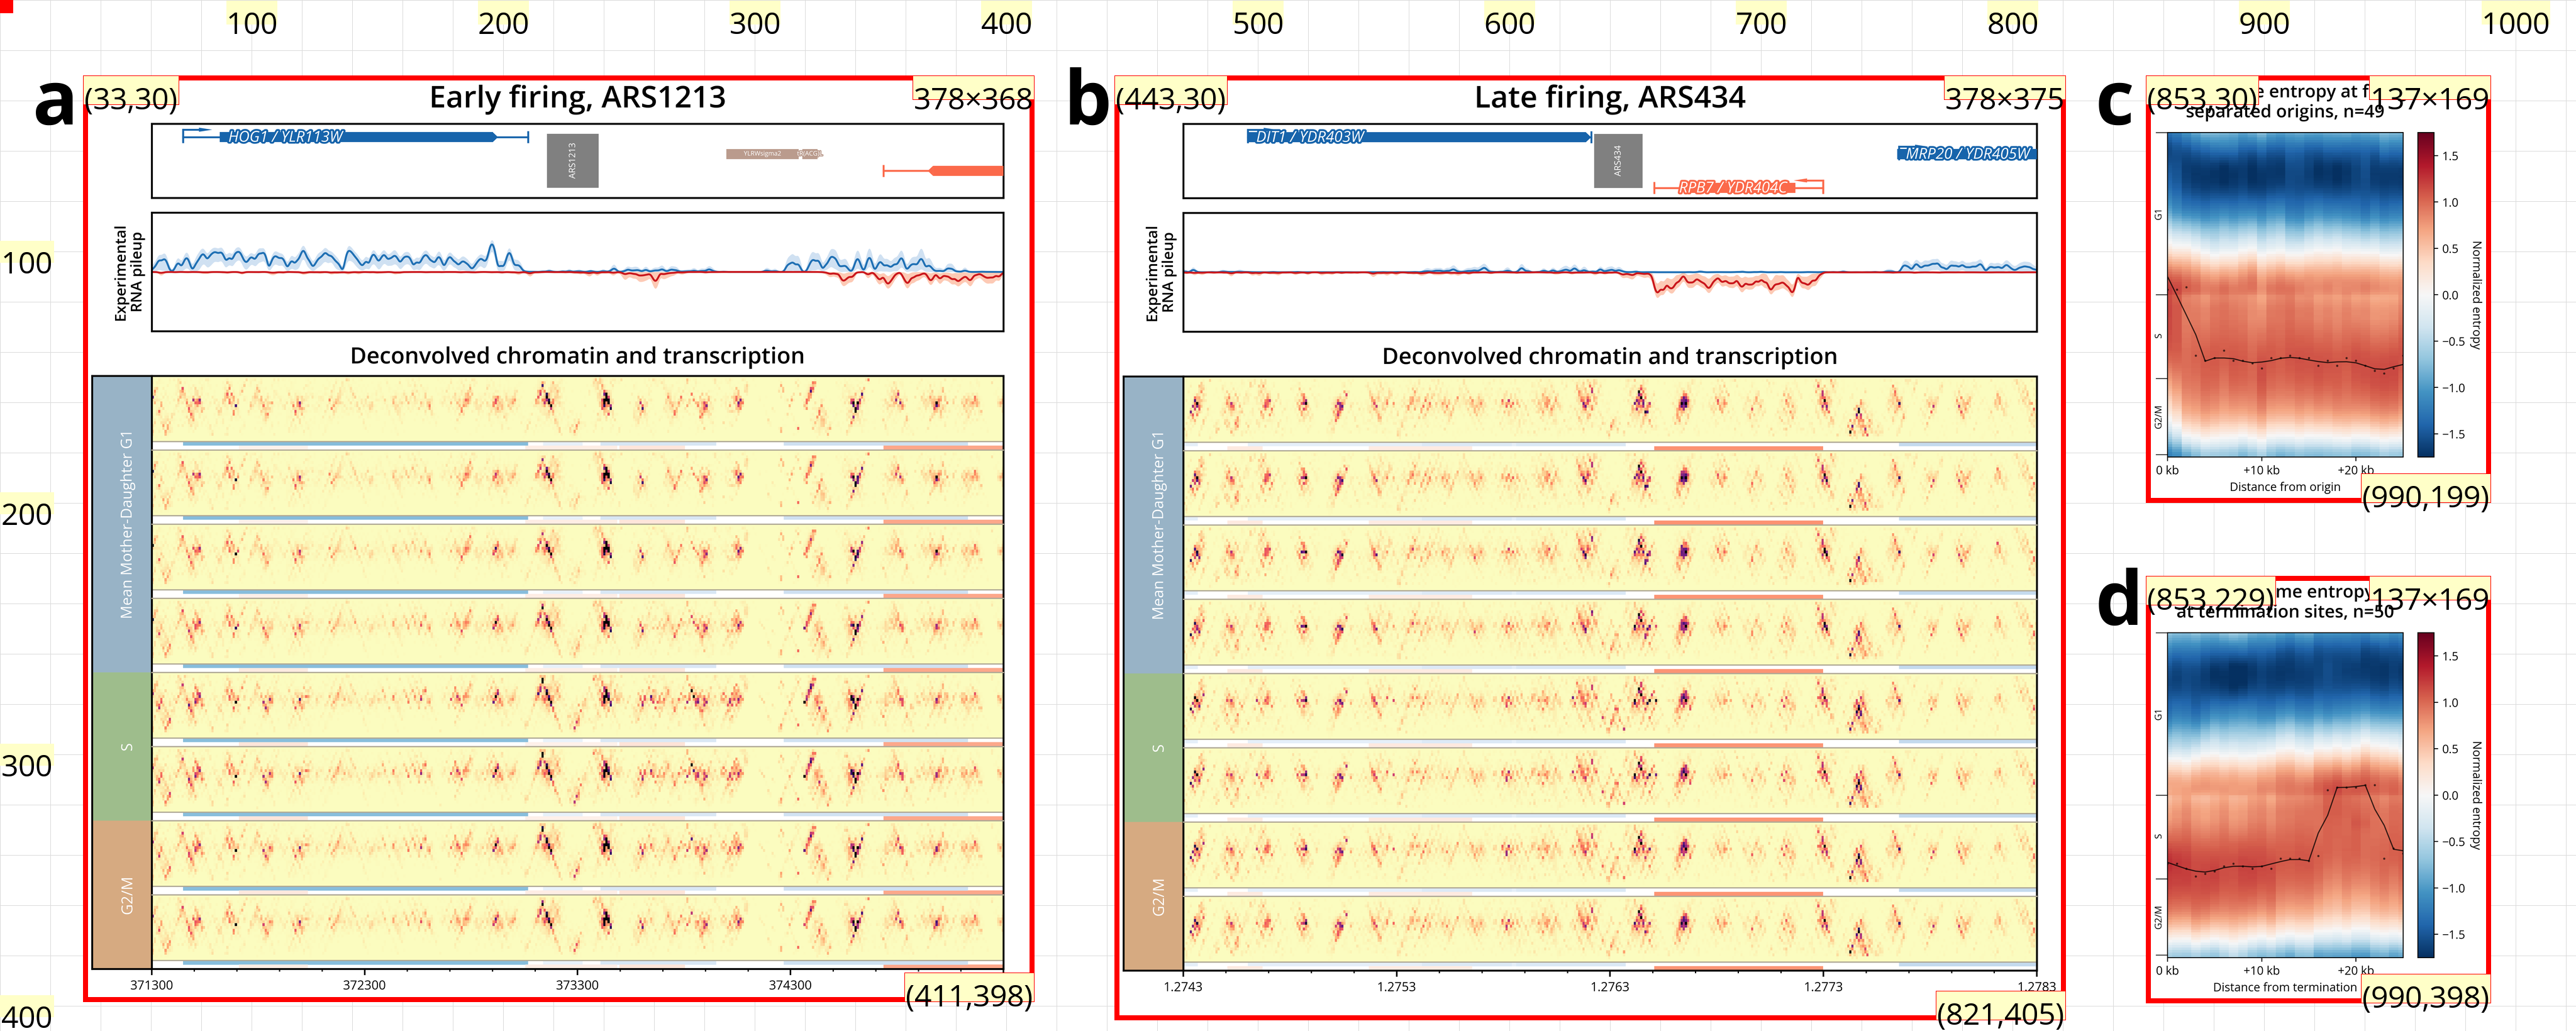

In [7]:
fig_origins.layout_panel()
display(Image('output/draft4_run/Figures/Debug/Figure4_Origins_debug.png'))

In [ ]:
from pipeline.origin_footprint_analysis_per_yl import OriginsFootprintAnalysis

footprint_analyzer = OriginsFootprintAnalysis()
footprint_analyzer.setup(fig_origins.genome_deconv_analysis, fig_origins.origin_timings)


In [23]:
origins = footprint_analyzer.origins
g1_and_g2 = origins[origins.footprint_class == 'g1_and_g2_footprint']
g1_only = origins[origins.footprint_class == 'g1_only_footprint']

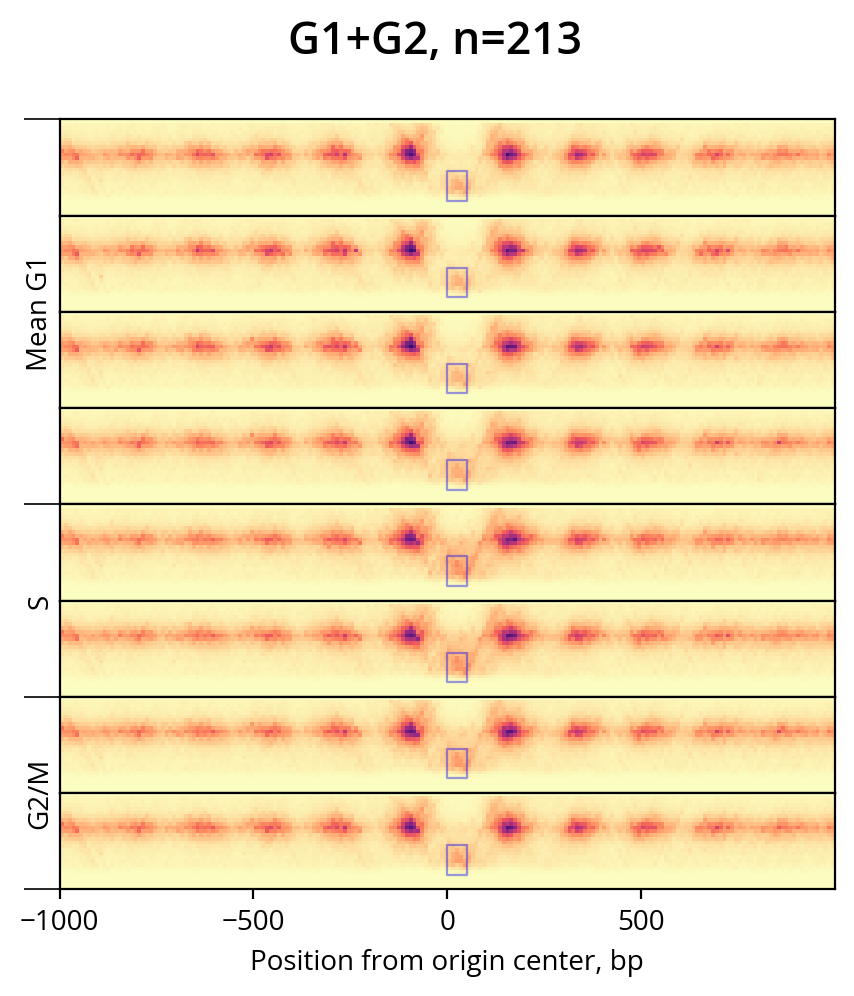

In [58]:
footprint_analyzer.plot_composite_heatmap(g1_and_g2, 'G1+G2')

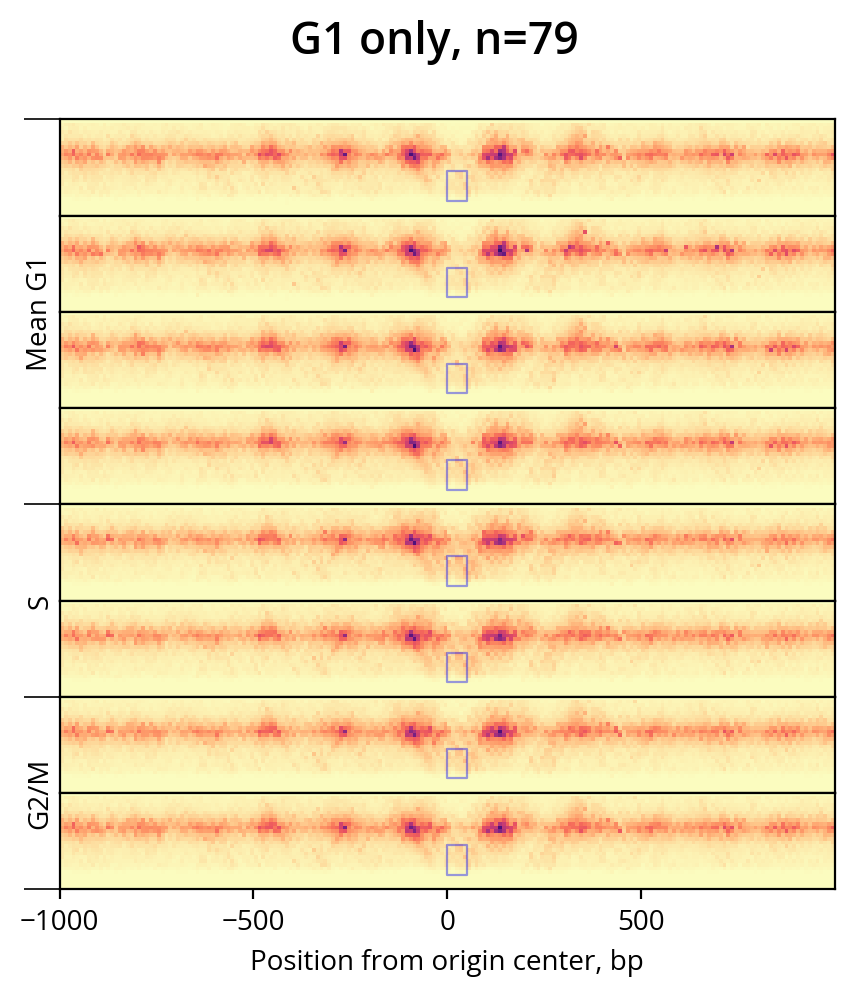

In [59]:
footprint_analyzer.plot_composite_heatmap(g1_only, 'G1 only')

In [49]:
footprint_analyzer.compute_footprint_timecourses(origin_sets={'G1 only': g1_only, 
    'G1 & G2': g1_and_g2})

Text(0.5, 1.0, 'Small fragment footprint (deconvolved)')

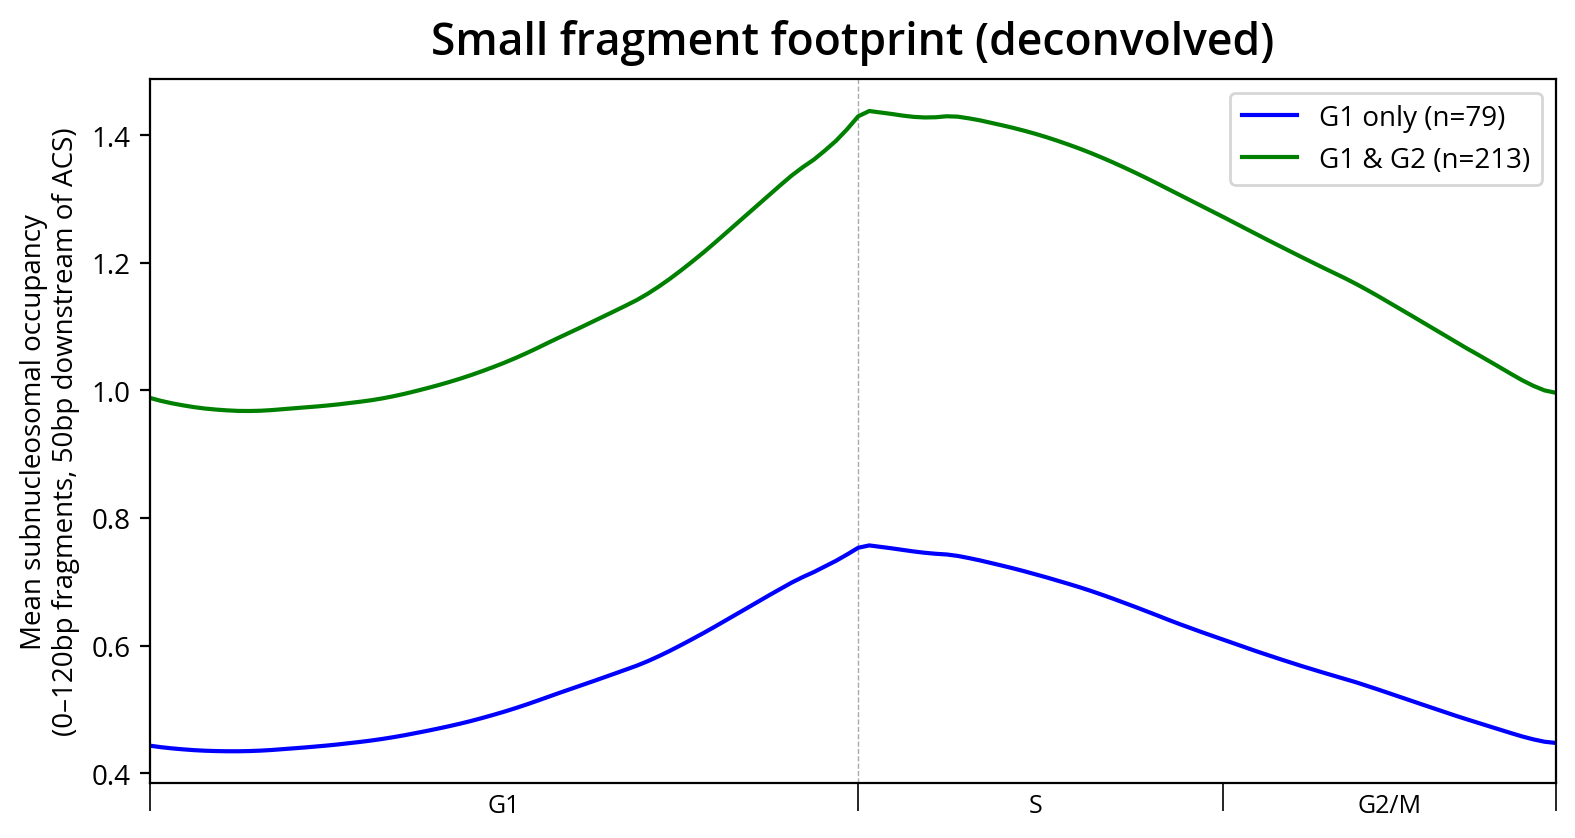

In [53]:
footprint_analyzer.plot_footprint_timecourse()
plt.title("Small fragment footprint (deconvolved)", pad=9, fontweight='demi', 
         fontsize=16)


In [60]:
footprint_analyzer.compute_efficiency_correlation()

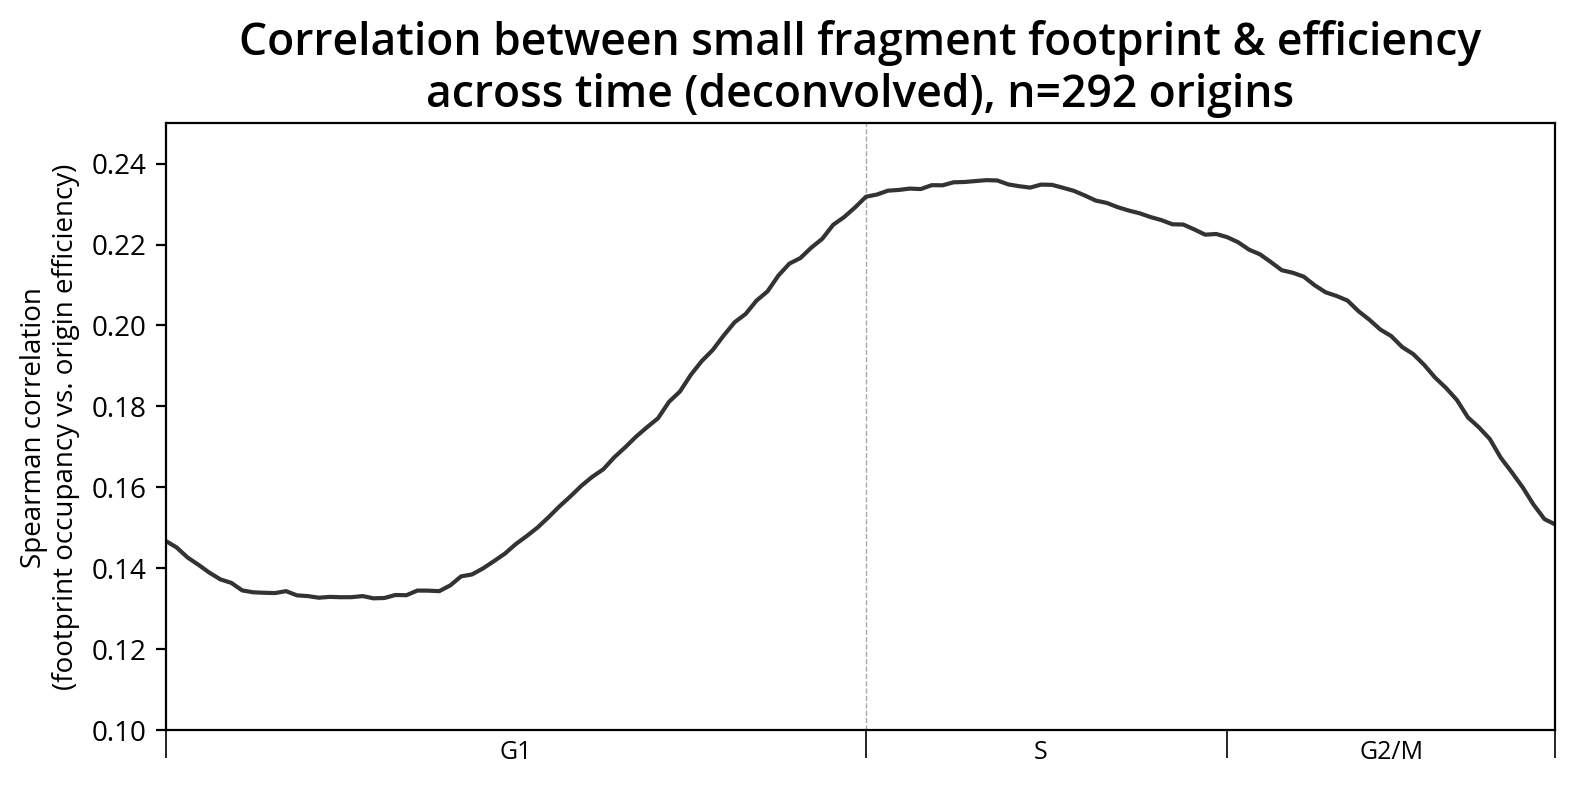

In [61]:
footprint_analyzer.plot_efficiency_correlation()